Device: cuda
Using global train min/max for encoder input normalization: min=-1.230065e-07, max=1.210273e-07
Training (paper schedule): epochs= 200 batch_size= 256
Epoch 1/200 | lr=5.00e-05 | train_loss=1.8141e-01 | val_NMSE=11.534 dB | best=11.534 dB | t_epoch=5.4s
Epoch 10/200 | lr=6.35e-04 | train_loss=1.8374e-04 | val_NMSE=-13.998 dB | best=-13.998 dB | t_epoch=3.0s
Epoch 20/200 | lr=1.28e-03 | train_loss=5.0777e-05 | val_NMSE=-17.826 dB | best=-17.826 dB | t_epoch=3.2s
Epoch 30/200 | lr=1.94e-03 | train_loss=4.7135e-05 | val_NMSE=-18.711 dB | best=-18.711 dB | t_epoch=3.0s
Epoch 40/200 | lr=1.99e-03 | train_loss=5.4497e-05 | val_NMSE=-19.214 dB | best=-19.214 dB | t_epoch=3.0s
Epoch 50/200 | lr=1.94e-03 | train_loss=4.6329e-05 | val_NMSE=-19.767 dB | best=-19.767 dB | t_epoch=3.0s
Epoch 60/200 | lr=1.86e-03 | train_loss=3.5423e-05 | val_NMSE=-20.010 dB | best=-20.197 dB | t_epoch=3.0s
Epoch 70/200 | lr=1.76e-03 | train_loss=3.1622e-05 | val_NMSE=-20.551 dB | best=-20.551 dB | t_ep

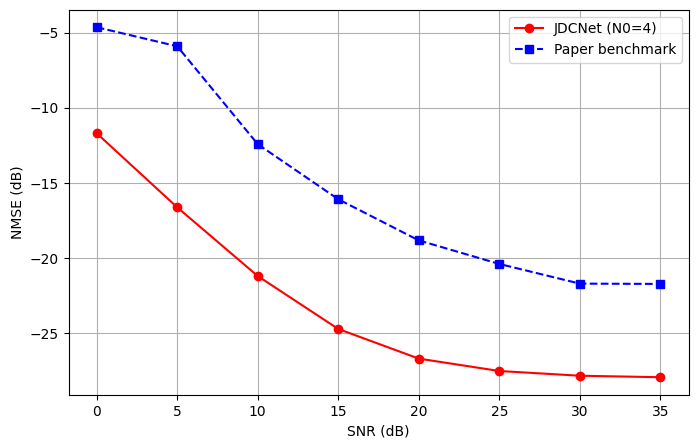

In [1]:
# jdcnet_paper_final_with_flexible_loader.py
# Paper-faithful JDCNet reproduction (encoder/decoder/quant + training schedule)
# Adds a robust loader to handle DataParallel 'module.' prefix mismatch on load,
# and safe saving to /kaggle/output. No other logic changed.

import os, random, math, time, shutil
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ---------------- reproducibility ----------------
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------- flexible loader helper ----------------
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)

    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if 'model_state_dict' in sd:
            sd = sd['model_state_dict']
        elif 'state_dict' in sd:
            sd = sd['state_dict']

    if not isinstance(sd, dict):
        raise RuntimeError(f"Loaded object from {path} is not a state_dict mapping.")

    sd_keys = list(sd.keys())
    if len(sd_keys) == 0:
        raise RuntimeError("Loaded state_dict is empty")

    saved_has_module = sd_keys[0].startswith('module.')
    model_is_datapar = isinstance(model, nn.DataParallel)

    if verbose:
        print(f"[loader] Loaded state_dict from {path}. saved_has_module={saved_has_module}, model_is_datapar={model_is_datapar}")

    if saved_has_module and not model_is_datapar:
        new_sd = {k[len('module.'):]: v for k, v in sd.items()}
        sd = new_sd
        if verbose: print("[loader] Stripped 'module.' prefix from saved keys.")
    elif (not saved_has_module) and model_is_datapar:
        new_sd = {'module.' + k: v for k, v in sd.items()}
        sd = new_sd
        if verbose: print("[loader] Added 'module.' prefix to saved keys to match DataParallel model.")

    try:
        model.load_state_dict(sd)
        if verbose: print("[loader] State dict loaded successfully (strict).")
    except Exception as e:
        if verbose:
            print("[loader] Strict load failed. Attempting non-strict load for diagnostics...")
        res = model.load_state_dict(sd, strict=False)
        if verbose:
            print("[loader] Non-strict load result:", res)
        raise e

# ---------------- STE Quantizer ----------------
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        levels = 2 ** q_bits - 1
        x_clamped = torch.clamp(x, 0.0, 1.0)
        q = torch.round(x_clamped * levels) / levels
        return q
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# ---------------- ResBlock ----------------
class PaperResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        identity = x
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return self.relu(out + identity)

# ---------------- JDCNet ----------------
class JDCNet_Paper(nn.Module):
    def __init__(self, M=16, N=64, N0=2, gamma=1/16, q_bits=8, B=4, decoder_ch=16, quant_enabled=True):
        super().__init__()
        self.M, self.N, self.N0 = M, N, N0
        self.Np = N // N0
        self.q_bits = q_bits
        self.quant_enabled = quant_enabled
        self.C = int(gamma * 32 * N0)

        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=4, stride=2, padding=1),  
            nn.ReLU(inplace=True),
            nn.Conv2d(16, self.C, kernel_size=4, stride=2, padding=1)  
        )

        self.decoder_tconv1 = nn.ConvTranspose2d(self.C, decoder_ch, kernel_size=4, stride=2, padding=1)
        self.decoder_tconv2 = nn.ConvTranspose2d(decoder_ch, decoder_ch, kernel_size=4, stride=2, padding=1)

        self.resblocks = nn.Sequential(*[PaperResBlock(decoder_ch) for _ in range(B)])

        # DYNAMIC UPSAMPLING: Automatically scales kernel/stride/padding based on N0 to restore width to N
        self.final_tconv = nn.ConvTranspose2d(
            decoder_ch, 
            decoder_ch, 
            kernel_size=(1, 2 * N0), 
            stride=(1, N0), 
            padding=(0, N0 // 2)
        )
        self.final_conv = nn.Conv2d(decoder_ch, 2, kernel_size=3, padding=1)

    def forward(self, x_norm, quant_bits=None):
        b = x_norm.shape[0]
        z = self.encoder(x_norm)  

        z_shape = z.shape
        v = z.view(b, -1)  
        v_min = v.min(dim=1, keepdim=True)[0]
        v_max = v.max(dim=1, keepdim=True)[0]
        denom = (v_max - v_min).clamp_min(1e-12)

        if self.quant_enabled:
            qbits = self.q_bits if quant_bits is None else quant_bits
            v_norm = (v - v_min) / denom  
            v_q = QuantizeSTE.apply(v_norm, qbits)
            v_deq = v_q * denom + v_min
        else:
            v_deq = v  

        z_deq = v_deq.view(*z_shape)  

        y = torch.relu(self.decoder_tconv1(z_deq))
        y = torch.relu(self.decoder_tconv2(y))
        y = self.resblocks(y)
        y = torch.relu(self.final_tconv(y))
        out = self.final_conv(y)  
        return out

# ---------------- Dataset ----------------
class RISChannelDataset(Dataset):
    def __init__(self, mat_file, split='train'):
        data = sio.loadmat(mat_file)
        H_mat = np.transpose(data['H'], (2, 0, 1)).astype(np.complex64)  
        G_mat = np.transpose(data['G'], (2, 0, 1)).astype(np.complex64)  
        H_cascade = G_mat.transpose(0, 2, 1) * H_mat  

        if split == 'train':
            samples = H_cascade[:40000]
        elif split == 'val':
            samples = H_cascade[40000:44000]
        else:
            samples = H_cascade[44000:48000]

        real = np.real(samples).astype(np.float32)
        imag = np.imag(samples).astype(np.float32)
        stacked = np.stack([real, imag], axis=1)  
        stacked = stacked.transpose(0,1,3,2)      
        self.data_phys = torch.tensor(stacked, dtype=torch.float32)

    def __len__(self): return len(self.data_phys)
    def __getitem__(self, idx): return self.data_phys[idx]

# ---------------- LS generator ----------------
def generate_ls_physical(H_phys, N0, snr_db):
    b, c, m, n = H_phys.shape
    assert n % N0 == 0
    H_grouped = H_phys.view(b, c, m, n//N0, N0).mean(dim=-1)  
    power_per_sample = torch.mean(H_grouped[:,0]**2 + H_grouped[:,1]**2, dim=[1,2])  
    snr_linear = 10.0 ** (snr_db / 10.0)
    noise_var = power_per_sample / snr_linear
    noise_std = torch.sqrt(noise_var / 2.0).view(b,1,1,1)
    noise = torch.randn_like(H_grouped) * noise_std
    return H_grouped + noise

# ---------------- Learning rate schedule ----------------
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * (epoch / max(1, Tw))
    else:
        t_rel = (epoch - Tw) / max(1, (T - Tw))
        return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * t_rel))

# ---------------- Full pipeline ----------------
def run_paper_pipeline(mat_path='/kaggle/input/datasets/hades1998/dataset-mlwl/RIS_Channels_1.mat',
                       N0=4, gamma=1/16, q_bits=8,
                       batch_size=256, epochs=200, Tw=30, eta_max=2e-3, eta_min=5e-5,
                       device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)

    train_ds = RISChannelDataset(mat_path, 'train')
    val_ds = RISChannelDataset(mat_path, 'val')
    test_ds = RISChannelDataset(mat_path, 'test')

    train_min = float(train_ds.data_phys.min()); train_max = float(train_ds.data_phys.max())
    print(f"Using global train min/max for encoder input normalization: min={train_min:.6e}, max={train_max:.6e}")

    def minmax_norm(x):
        return (x - train_min) / (train_max - train_min + 1e-12)
    def minmax_denorm(x):
        return x * (train_max - train_min) + train_min

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

    model = JDCNet_Paper(M=16, N=64, N0=N0, gamma=gamma, q_bits=q_bits, B=4, decoder_ch=16, quant_enabled=True)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(device)

    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_val_nmse = 1e9
    best_path = '/kaggle/working/jdcnet_paper_best.pth'
    out_path = '/kaggle/output/jdcnet_paper_best.pth'

    print("Training (paper schedule): epochs=", epochs, "batch_size=", batch_size)
    for epoch in range(epochs):
        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups:
            g['lr'] = lr

        train_loss = 0.0
        t0 = time.time()
        for batch in train_loader:
            batch = batch.to(device)  
            snr_train = random.uniform(10, 30)
            H_ls_phys = generate_ls_physical(batch, N0=N0, snr_db=snr_train)  
            H_ls_norm = minmax_norm(H_ls_phys).to(device)
            H_orig_norm = minmax_norm(batch).to(device)

            optimizer.zero_grad()
            out_norm = model(H_ls_norm)  
            loss = criterion(out_norm, H_orig_norm)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        t1 = time.time()

        model.eval()
        val_mse = 0.0
        val_power = 0.0
        with torch.no_grad():
            for vb in val_loader:
                vb = vb.to(device)
                H_ls_p = generate_ls_physical(vb, N0=N0, snr_db=15.0)
                H_ls_n = minmax_norm(H_ls_p).to(device)
                out_n = model(H_ls_n)
                out_phys = minmax_denorm(out_n.cpu())
                val_mse += torch.sum((out_phys.to(device) - vb)**2).item()
                val_power += torch.sum(vb**2).item()
        val_nmse_db = 10.0 * math.log10(val_mse / (val_power + 1e-12))

        if val_nmse_db < best_val_nmse:
            best_val_nmse = val_nmse_db
            if isinstance(model, nn.DataParallel):
                model_state = model.module.state_dict()
            else:
                model_state = model.state_dict()

            torch.save(model_state, best_path)

            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                if os.path.exists(best_path):
                    shutil.copy(best_path, out_path)
            except Exception as e:
                pass

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | lr={lr:.2e} | train_loss={train_loss:.4e} | val_NMSE={val_nmse_db:.3f} dB | best={best_val_nmse:.3f} dB | t_epoch={t1-t0:.1f}s")

    load_state_dict_flexible(best_path, model, map_location=device, verbose=True)
    model.eval()

    snrs = [0,5,10,15,20,25,30,35]
    nmse_results = []
    with torch.no_grad():
        for snr in snrs:
            total_mse = 0.0
            total_power = 0.0
            for tb in test_loader:
                tb = tb.to(device)
                H_ls_phys = generate_ls_physical(tb, N0=N0, snr_db=snr)
                H_ls_norm = minmax_norm(H_ls_phys).to(device)
                out_norm = model(H_ls_norm)
                out_phys = minmax_denorm(out_norm.cpu())
                total_mse += torch.sum((out_phys.to(device) - tb)**2).item()
                total_power += torch.sum(tb**2).item()
            nmse_db = 10.0 * math.log10(total_mse / (total_power + 1e-12))
            nmse_results.append(nmse_db)
            print(f"SNR {snr:2d} dB -> NMSE {nmse_db:.3f} dB")

    plt.figure(figsize=(8,5))
    plt.plot(snrs, nmse_results, 'r-o', label='JDCNet (N0=4)')
    plt.plot(snrs, [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74],
             'b--s', label='Paper benchmark')
    plt.xlabel('SNR (dB)'); plt.ylabel('NMSE (dB)'); plt.grid(True); plt.legend(); plt.show()

    return model, nmse_results

if __name__ == '__main__':
    mat_path = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat'
    # Adjusted to N0=4 execution
    model, res = run_paper_pipeline(mat_path=mat_path, N0=4, gamma=1/16, q_bits=8,
                                    batch_size=256, epochs=200, Tw=30, eta_max=2e-3, eta_min=5e-5)